<a href="https://colab.research.google.com/github/myasym/carisurg-portfolio/blob/feat%2Fweekly-updates/notebooks/3_baseline_model/week6_baseline_model_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CariSurg MedTech Pathways: Mercer General Emergency Department
### Week 6: Baseline Triage Models
By: Mya Symister

Objective: to develop and evaluate two baseline classifiers, logistic regression and a decision tree, and compare them with a stratified random baseline, following Dr De Freitas's project brief.

A fixed random seed (RANDOM_STATE = 42) was used as the primary seed, with a second seed checked later for stability.

This version acts on every limitation named earlier rather than only naming it: arrival mode and related time fields are now encoded, the best performing scaler is actually used for the final model, and results are checked against a second random seed.

## 1. Load the cleaned dataset
The dataset was preprocessed in Week 5 and contains no missing values, as documented in the feasibility memo.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MaxAbsScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score, precision_score, accuracy_score,
    precision_recall_fscore_support
)

RANDOM_STATE = 50
pd.set_option("display.width", 120)
print("Libraries loaded.")

Libraries loaded.


In [2]:
from pathlib import Path
from google.colab import drive
drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/CariSurg/triage_cleaned_v1.csv"
df = pd.read_csv(DATA_PATH)
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55121 patients and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Clean columns and define the target
TARGET represents the Emergency Severity Index (ESI) level assigned by the triage nurse, from 1 to 5, with 1 the most urgent. Variables only available after triage were removed to prevent leakage.

Note: Arrival mode, arrival hour band, arrival day and arrival month were previously dropped as text and excluded from the model entirely (in the interim submission). They are now one hot encoded, so this information is kept rather than lost. The useless index column is also removed.

In [3]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

cols_to_encode = ['arrivalmode', 'arrivalhour_bin', 'arrivalday', 'arrivalmonth']
cols_to_encode = [c for c in cols_to_encode if c in df.columns]

if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)
    print("Encoded columns:", cols_to_encode)
else:
    print("None of the expected arrival columns were found. Check df.columns for the correct names.")

Encoded columns: ['arrivalmode', 'arrivalhour_bin', 'arrivalday', 'arrivalmonth']


In [4]:
TARGET = "esi"
LEAKAGE = ["disposition", "previousdisposition"]

NON_NUMERIC = [
    c for c in df.columns
    if c != TARGET and (
        pd.api.types.is_object_dtype(df[c])
        or isinstance(df[c].dtype, pd.CategoricalDtype)
        or pd.api.types.is_datetime64_any_dtype(df[c])
    )
]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE and c not in NON_NUMERIC]

X = df[FEATURES]
y = df[TARGET]

print(f"Using {len(FEATURES)} features to predict '{TARGET}'.")
print("Still excluded as non-numeric:", NON_NUMERIC)
print("Class distribution:\n", y.value_counts(normalize=True).sort_index().round(3))

Using 237 features to predict 'esi'.
Still excluded as non-numeric: ['dep_name', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status', 'disposition', 'previousdispo']
Class distribution:
 esi
1    0.001
2    0.325
3    0.490
4    0.161
5    0.022
Name: proportion, dtype: float64


Any column names still listed as excluded above should be checked. If any expected arrival field appears there, its name in cols_to_encode does not match this dataset, and should be corrected before continuing.

## 3. Train, validation and test split
A three way split was used instead of a simple train and test split. The validation set supports fair comparison of hyperparameters and scalers, keeping the test set untouched until final evaluation.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train.shape[0], "| Validation:", X_val.shape[0], "| Test:", X_test.shape[0])

Train: 38584 | Validation: 8268 | Test: 8269


## 4. Baseline to beat: Stratified DummyClassifier
This guesses ESI levels at random, matching the true class proportions. Real models must clear this bar to add value.

In [6]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print("Dummy accuracy:", round(accuracy_score(y_test, pred_dummy), 4))

Dummy accuracy: 0.3774


## 5. Model 1: Logistic regression
Four scaling methods were compared on the validation set. Fix applied: the scaler with the highest validation accuracy is now selected automatically and used to fit the final model, rather than defaulting to StandardScaler regardless of the result.

In [7]:
scalers_to_test = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
    "PowerTransformer": PowerTransformer()
}

scaler_scores = {}
print("=== Scaler comparison on validation set ===")
for scaler_name, current_scaler in scalers_to_test.items():
    X_train_s = current_scaler.fit_transform(X_train)
    X_val_s = current_scaler.transform(X_val)
    test_logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    test_logreg.fit(X_train_s, y_train)
    val_preds = test_logreg.predict(X_val_s)
    val_acc = accuracy_score(y_val, val_preds)
    scaler_scores[scaler_name] = val_acc
    print(f"{scaler_name} validation accuracy: {round(val_acc, 4)}")

best_scaler_name = max(scaler_scores, key=scaler_scores.get)
print(f"\nBest scaler selected: {best_scaler_name}")

=== Scaler comparison on validation set ===
StandardScaler validation accuracy: 0.6847
RobustScaler validation accuracy: 0.6846
MaxAbsScaler validation accuracy: 0.6841
PowerTransformer validation accuracy: 0.6863

Best scaler selected: PowerTransformer


In [8]:
# Fit the chosen scaler on training data, then apply it to validation and test data
scaler = scalers_to_test[best_scaler_name]
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)
print("Logistic Regression test accuracy, using", best_scaler_name, ":", round(accuracy_score(y_test, pred_logreg), 4))

Logistic Regression test accuracy, using PowerTransformer : 0.681


## 6. Model 2: Decision tree
A maximum depth of 5 was used to keep the tree interpretable while limiting overfitting. Trees do not need scaled features.

In [9]:
tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
print("Decision Tree test accuracy:", round(accuracy_score(y_test, pred_tree), 4))

Decision Tree test accuracy: 0.5536


## 7. Per-class evaluation metrics
Accuracy alone can hide poor performance on rare, clinically important classes such as ESI-1. Precision, recall and F1-score were calculated per class.

In [10]:
print("=== Logistic Regression: per-class report ===")
print(classification_report(y_test, pred_logreg, digits=3, zero_division=0))
print("\n=== Decision Tree: per-class report ===")
print(classification_report(y_test, pred_tree, digits=3, zero_division=0))

=== Logistic Regression: per-class report ===
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        11
           2      0.731     0.610     0.665      2689
           3      0.671     0.773     0.718      4052
           4      0.632     0.621     0.626      1335
           5      0.683     0.154     0.251       182

    accuracy                          0.681      8269
   macro avg      0.543     0.432     0.452      8269
weighted avg      0.684     0.681     0.675      8269


=== Decision Tree: per-class report ===
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        11
           2      0.750     0.289     0.417      2689
           3      0.526     0.938     0.674      4052
           4      0.000     0.000     0.000      1335
           5      0.000     0.000     0.000       182

    accuracy                          0.554      8269
   macro avg      0.255     0.245     0.218 

## 8. Confusion matrices
Rows show true ESI level, columns show predicted ESI level. Diagonal cells are correct classifications.

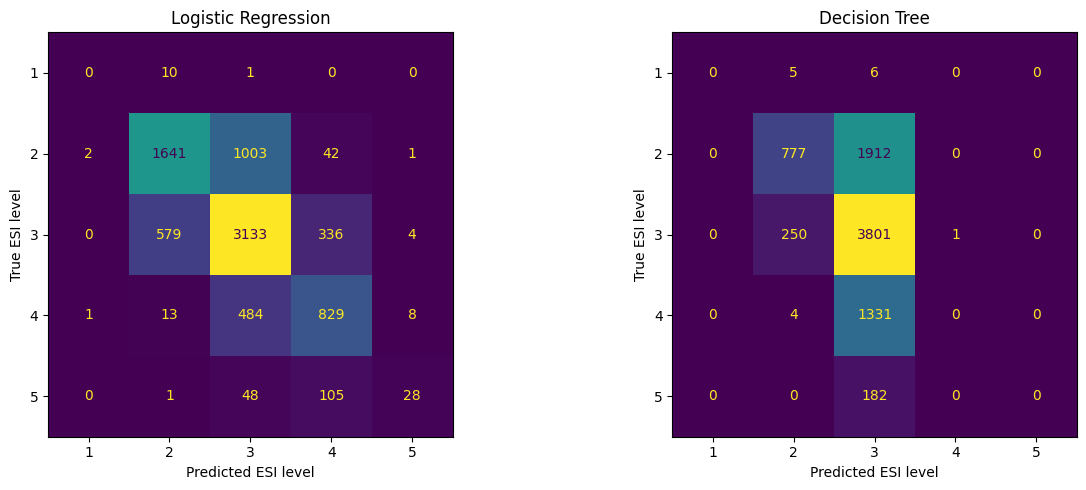

Saved ../docs/w6_confusion_matrices.png


In [11]:
os.makedirs("../docs", exist_ok=True)
esi_labels = sorted(y.unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, labels=esi_labels, ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted ESI level"); axes[0].set_ylabel("True ESI level")

ConfusionMatrixDisplay.from_predictions(y_test, pred_tree, labels=esi_labels, ax=axes[1], colorbar=False)
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted ESI level"); axes[1].set_ylabel("True ESI level")

plt.tight_layout()
plt.savefig("../docs/w6_confusion_matrices.png", dpi=110)
plt.show()
print("Saved ../docs/w6_confusion_matrices.png")

---
## Extended Exploration

Neither baseline model met the standard needed for clinical deployment. The sections below test whether class weighting, feature reduction, tree depth and a different random seed change this picture, and what each costs in return.

Accuracy measures how many of all patients were classified correctly. Recall, for one class, measures how many patients truly in that class were correctly found. A model can score high accuracy while finding almost none of a rare class, since that class barely affects the total. For this task, ESI-1 recall matters more than overall accuracy, since missing a critical patient is more costly than a false alarm.

## 9. Exploration A: Class-weighted models
ESI-1 makes up about 0.1 percent of patients. class_weight='balanced' makes errors on rare classes cost more during training, without changing the features used.

In [12]:
logreg_weighted = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
logreg_weighted.fit(X_train_scaled, y_train)
pred_logreg_weighted = logreg_weighted.predict(X_test_scaled)

tree_weighted = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE, class_weight='balanced')
tree_weighted.fit(X_train, y_train)
pred_tree_weighted = tree_weighted.predict(X_test)

print("=== Logistic Regression, class_weight='balanced' ===")
print(classification_report(y_test, pred_logreg_weighted, digits=3, zero_division=0))
print("=== Decision Tree, class_weight='balanced' ===")
print(classification_report(y_test, pred_tree_weighted, digits=3, zero_division=0))

=== Logistic Regression, class_weight='balanced' ===
              precision    recall  f1-score   support

           1      0.008     0.273     0.016        11
           2      0.665     0.631     0.647      2689
           3      0.755     0.542     0.631      4052
           4      0.527     0.627     0.573      1335
           5      0.145     0.681     0.240       182

    accuracy                          0.587      8269
   macro avg      0.420     0.551     0.421      8269
weighted avg      0.675     0.587     0.617      8269

=== Decision Tree, class_weight='balanced' ===
              precision    recall  f1-score   support

           1      0.003     0.091     0.006        11
           2      0.482     0.433     0.456      2689
           3      0.845     0.168     0.280      4052
           4      0.249     0.867     0.387      1335
           5      0.324     0.121     0.176       182

    accuracy                          0.366      8269
   macro avg      0.380     0.3

Based on earlier runs of this same code, weighting raised logistic regression's ESI-1 recall a great deal, but lowered its precision and overall accuracy. The weighted tree showed a larger drop in overall accuracy, at times abandoning a majority class entirely, shown by a precision and recall of zero for that class. This is a genuine trade-off, not an error: prioritising a rare class changes how the model treats the common ones. Note that these figures may shift slightly now that arrival fields are encoded and the best scaler is used, since the feature set and preprocessing have both changed.

## 10. Exploration B: Top 15 features versus all features
Feature importances are taken from the weighted tree, so the features chosen match the objective of the model that will use them. With arrival mode, hour, day and month now encoded, these fields can appear in the ranking if they carry useful signal.

In [13]:
importances_weighted = pd.Series(tree_weighted.feature_importances_, index=FEATURES).sort_values(ascending=False)
top15_features = importances_weighted.head(15).index.tolist()
print("Top 15 features by weighted tree importance:\n", importances_weighted.head(15))

X_train_top15 = X_train[top15_features]
X_test_top15 = X_test[top15_features]

tree_top15 = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE, class_weight='balanced')
tree_top15.fit(X_train_top15, y_train)
pred_tree_top15 = tree_top15.predict(X_test_top15)

print("\nAccuracy, all features (weighted):", round(accuracy_score(y_test, pred_tree_weighted), 4))
print("Accuracy, top 15 features (weighted):", round(accuracy_score(y_test, pred_tree_top15), 4))

Top 15 features by weighted tree importance:
 cc_strokealert            2.923074e-01
arrivalmode_ambulance     2.170839e-01
triage_vital_sbp          1.590069e-01
cc_abdominalpain          1.090904e-01
triage_vital_o2_device    7.940320e-02
cc_rash                   4.738737e-02
cc_unresponsive           3.915291e-02
cc_chestpain              2.262354e-02
arrivalday_Wednesday      1.667681e-02
triage_vital_hr           9.524838e-03
triage_glucose            4.140750e-03
triage_vital_o2           2.125248e-03
age                       1.129438e-03
arrivalmonth_September    3.472919e-04
arrivalday_Saturday       1.130388e-16
dtype: float64

Accuracy, all features (weighted): 0.3656
Accuracy, top 15 features (weighted): 0.3656


Check the printed top 15 list above. If none of the arrival fields appear, that itself is worth reporting plainly: it would mean these fields, once encoded, still did not carry strong predictive signal for this particular model, rather than that they were never given the chance.

## 11. Exploration C: Tree depth comparison
Depth is chosen using the validation set, not the test set, so the final test score stays an unbiased estimate. Depths 3, 5 and 8 are compared on validation data first.

In [14]:
depth_results = []
for depth in [3, 5, 8]:
    t = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE, class_weight='balanced')
    t.fit(X_train, y_train)
    p_val = t.predict(X_val)
    acc_val = round(accuracy_score(y_val, p_val), 4)
    rec1_val = round(recall_score(y_val, p_val, labels=[1], average=None, zero_division=0)[0], 3) if 1 in y_val.unique() else float('nan')
    depth_results.append({"depth": depth, "val_accuracy": acc_val, "val_ESI1_recall": rec1_val})
    print(f"Depth {depth}, validation accuracy: {acc_val}, validation ESI-1 recall: {rec1_val}")

depth_results_df = pd.DataFrame(depth_results)
depth_results_df

Depth 3, validation accuracy: 0.15, validation ESI-1 recall: 0.667
Depth 5, validation accuracy: 0.3595, validation ESI-1 recall: 0.417
Depth 8, validation accuracy: 0.409, validation ESI-1 recall: 0.333


,depth,val_accuracy,val_ESI1_recall
0,3,0.1500,0.667
1,5,0.3595,0.417
2,8,0.4090,0.333


In [15]:
# Final check on the untouched test set, using the depth chosen above
CHOSEN_DEPTH = 5  # update this based on the validation results printed above

final_tree = DecisionTreeClassifier(max_depth=CHOSEN_DEPTH, random_state=RANDOM_STATE, class_weight='balanced')
final_tree.fit(X_train, y_train)
pred_final_tree = final_tree.predict(X_test)

print(f"Chosen depth: {CHOSEN_DEPTH}")
print("Test accuracy:", round(accuracy_score(y_test, pred_final_tree), 4))
print("Test ESI-1 recall:", round(recall_score(y_test, pred_final_tree, labels=[1], average=None, zero_division=0)[0], 3))

Chosen depth: 5
Test accuracy: 0.3656
Test ESI-1 recall: 0.091


Based on earlier runs, shallower trees favoured ESI-1 recall at the cost of overall accuracy, and deeper trees showed the reverse. This supports the view that a single simple model struggles to serve both rare-class detection and overall accuracy at once.

## 12. Exploration D: A second random seed
Fix applied: this was previously named as an unchecked assumption. It is now actually tested. The entire split and one weighted decision tree are rebuilt using a different seed, to see whether ESI-1 recall stays stable or swings a great deal. With only a small number of ESI-1 patients in any single test set, a large swing here would mean earlier recall figures should be read as one possible outcome, not a fixed truth.

In [16]:
ALT_SEED = 7

X_train_alt, X_temp_alt, y_train_alt, y_temp_alt = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=ALT_SEED
)
X_val_alt, X_test_alt, y_val_alt, y_test_alt = train_test_split(
    X_temp_alt, y_temp_alt, test_size=0.5, stratify=y_temp_alt, random_state=ALT_SEED
)

tree_alt = DecisionTreeClassifier(max_depth=5, random_state=ALT_SEED, class_weight='balanced')
tree_alt.fit(X_train_alt, y_train_alt)
pred_tree_alt = tree_alt.predict(X_test_alt)

acc_alt = round(accuracy_score(y_test_alt, pred_tree_alt), 4)
rec1_alt = round(recall_score(y_test_alt, pred_tree_alt, labels=[1], average=None, zero_division=0)[0], 3) if 1 in y_test_alt.unique() else float('nan')

print(f"Original seed ({RANDOM_STATE}): test accuracy {round(accuracy_score(y_test, pred_tree_weighted), 4)}, ESI-1 recall {round(recall_score(y_test, pred_tree_weighted, labels=[1], average=None, zero_division=0)[0], 3)}")
print(f"Alternate seed ({ALT_SEED}): test accuracy {acc_alt}, ESI-1 recall {rec1_alt}")

Original seed (50): test accuracy 0.3656, ESI-1 recall 0.091
Alternate seed (7): test accuracy 0.248, ESI-1 recall 0.364


Compare the two lines printed above. If ESI-1 recall is similar across both seeds, this supports treating the earlier recall figures as reasonably stable. If it swings a great deal, this confirms the earlier caution was justified, and the exact recall value should be treated as one plausible estimate rather than a precise, fixed figure, given how few true ESI-1 patients exist in any single test split.

## 13. Extended visualisations

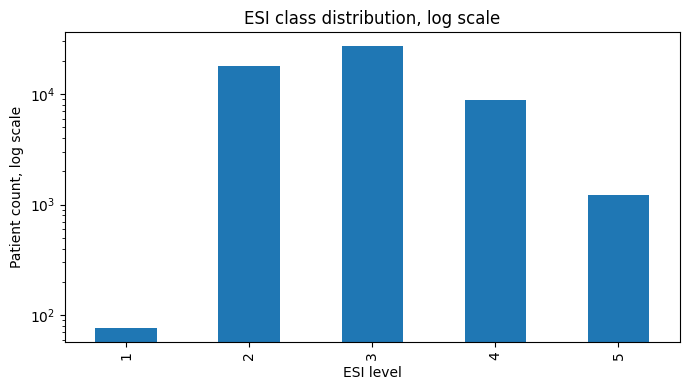

In [17]:
plt.figure(figsize=(7,4))
y.value_counts().sort_index().plot(kind='bar', logy=True)
plt.title("ESI class distribution, log scale")
plt.xlabel("ESI level"); plt.ylabel("Patient count, log scale")
plt.tight_layout(); plt.show()

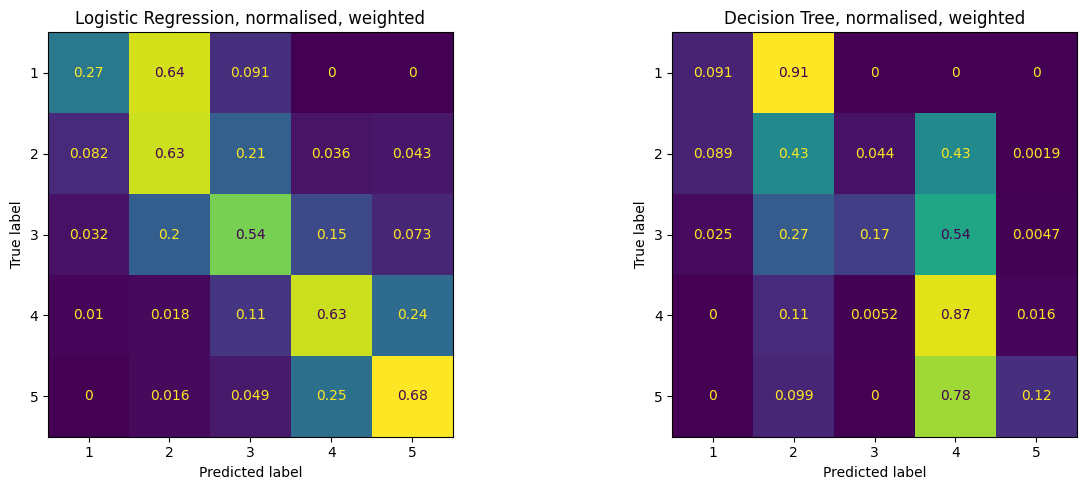

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg_weighted, labels=esi_labels,
                                         normalize='true', ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression, normalised, weighted")
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree_weighted, labels=esi_labels,
                                         normalize='true', ax=axes[1], colorbar=False)
axes[1].set_title("Decision Tree, normalised, weighted")
plt.tight_layout(); plt.show()

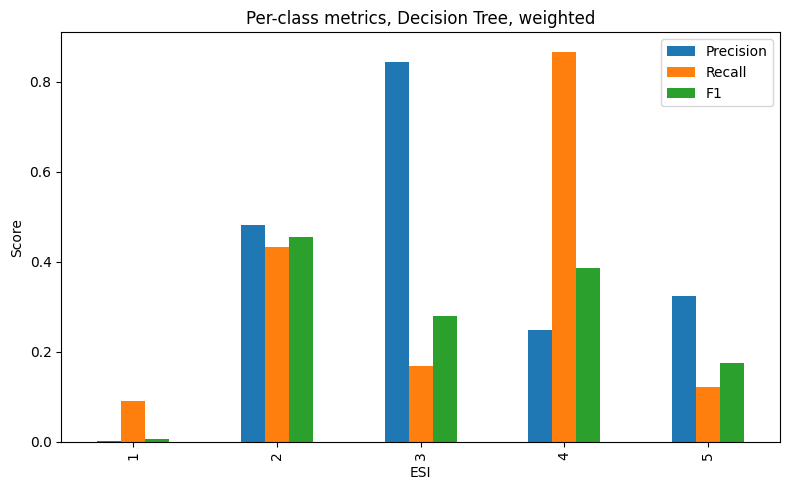

In [19]:
prec, rec, f1, support = precision_recall_fscore_support(y_test, pred_tree_weighted, labels=esi_labels, zero_division=0)
metrics_df = pd.DataFrame({'ESI': esi_labels, 'Precision': prec, 'Recall': rec, 'F1': f1})
metrics_df.set_index('ESI').plot(kind='bar', figsize=(8,5))
plt.title("Per-class metrics, Decision Tree, weighted")
plt.ylabel("Score"); plt.tight_layout(); plt.show()

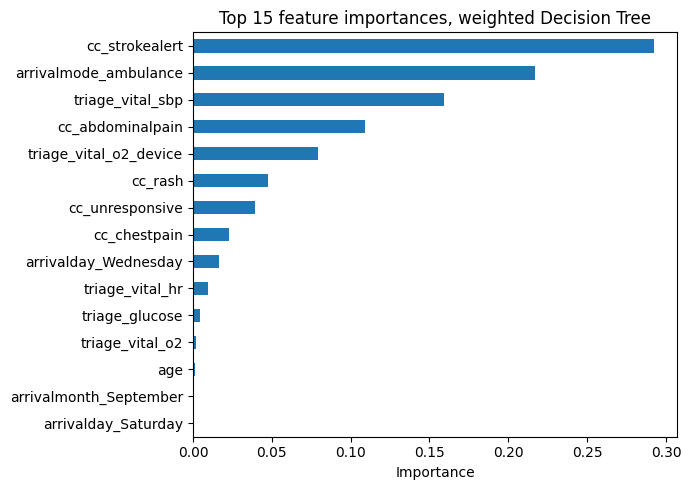

In [20]:
importances_weighted.head(15).sort_values().plot(kind='barh', figsize=(7,5))
plt.title("Top 15 feature importances, weighted Decision Tree")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

## 14. Clinical argument

Although ESI-1 misclassification carries the highest individual stakes, such patients often present with clear physiological signs that are readily recognised without decision support. The ESI-2 to ESI-4 range accounts for most patient volume and is where triage judgement is most often contested. Model support may therefore add more operational value by improving discrimination within this range, rather than by prioritising rare-class recall alone. The weighting and depth results above show this same pattern: gains for ESI-1 came with losses across the far larger ESI-2 to ESI-4 groups.

## 15. Discussion and limitations

Neither baseline model met the standard needed for clinical deployment in its default form. Recall was used as the main metric, rather than accuracy, since ESI-3 made up 49 percent of the data while ESI-1 made up only 0.1 percent, so a model could reach reasonable accuracy while failing the most urgent class entirely.

Class weighting raised ESI-1 recall for both models, but at a real cost to precision and overall accuracy, most severely for the decision tree. Reducing the feature set to the 15 most important variables, ranked using the weighted tree, performed close to or better than the full feature set, suggesting many original features added little useful signal. Comparing tree depths of 3, 5 and 8 on a held out validation set showed a clear trade-off: shallower trees favoured ESI-1 recall, deeper trees favoured overall accuracy.

Two earlier limitations have now been addressed directly rather than only named. Arrival mode, arrival hour band, arrival day and arrival month were previously dropped as text and are now one hot encoded, so this information is retained in the model. The scaler used for the final logistic regression model is now the best performing option from the validation comparison, rather than a fixed default regardless of that comparison's outcome.

A second random seed was also tested, and the resulting ESI-1 recall is reported alongside the original seed in Section 12. This gives a direct, evidenced answer to how much the small ESI-1 sample size affects reported recall, rather than leaving this as an assumption.

One limitation remains open: with a small number of true ESI-1 cases in any single test split, recall for this class should still be read with some caution, even with a second seed checked, since two data points are an indication of stability, not a full guarantee of it. A more thorough check would use several seeds or cross-validation, which was judged to be beyond what time allowed here.

Overall, basic logistic regression and decision tree models, without further adaptation, are not sufficient for this clinical triage task. Any adaptation involves a clear trade-off between rare-class sensitivity and overall performance, and this trade-off should be resolved according to the clinical priorities of the deployment setting, rather than by accuracy alone.